In [ ]:
Avg_acc_all_dataset=[]
Avg_acc_all_dataset_without_FS=[]
Avg_feature_all_dataset=[]
Avg_fitness_all_dataset=[]

In [ ]:
import pandas as pd
import numpy as np
import random
import math

In [ ]:
data=pd.read_csv('csv_result-JM1.csv')
data.head()

,id,LOC_BLANK,BRANCH_COUNT,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CYCLOMATIC_COMPLEXITY,DESIGN_COMPLEXITY,ESSENTIAL_COMPLEXITY,LOC_EXECUTABLE,HALSTEAD_CONTENT,...,HALSTEAD_LENGTH,HALSTEAD_LEVEL,HALSTEAD_PROG_TIME,HALSTEAD_VOLUME,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,LOC_TOTAL,label
0,1,1,7,0,0,4,3,1,11,25.05,...,59,0.09,174.56,280.54,28,31,15,12,14,N
1,2,5,37,0,6,19,16,10,85,81.19,...,351,0.04,3388.22,2225.29,147,204,59,22,98,N
2,3,2,1,0,0,1,1,1,10,56.44,...,37,0.35,25.17,159.91,17,20,15,5,14,Y
3,4,16,1,0,0,1,1,1,52,168.57,...,450,0.06,2697.42,2860.90,198,252,70,12,70,Y
4,5,0,7,0,0,4,2,3,9,14.32,...,26,0.13,47.33,110.45,9,17,7,12,12,N


In [ ]:
data.shape

(7782, 23)

In [ ]:
rows, columns= data.shape[0], data.shape[1]

#Separate the features and output column

y=data.iloc[:,-1]
tdata=data.iloc[:,0:-1]
tdata

,id,LOC_BLANK,BRANCH_COUNT,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CYCLOMATIC_COMPLEXITY,DESIGN_COMPLEXITY,ESSENTIAL_COMPLEXITY,LOC_EXECUTABLE,HALSTEAD_CONTENT,...,HALSTEAD_ERROR_EST,HALSTEAD_LENGTH,HALSTEAD_LEVEL,HALSTEAD_PROG_TIME,HALSTEAD_VOLUME,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,LOC_TOTAL
0,1,1,7,0,0,4,3,1,11,25.05,...,0.09,59,0.09,174.56,280.54,28,31,15,12,14
1,2,5,37,0,6,19,16,10,85,81.19,...,0.74,351,0.04,3388.22,2225.29,147,204,59,22,98
2,3,2,1,0,0,1,1,1,10,56.44,...,0.05,37,0.35,25.17,159.91,17,20,15,5,14
3,4,16,1,0,0,1,1,1,52,168.57,...,0.95,450,0.06,2697.42,2860.90,198,252,70,12,70
4,5,0,7,0,0,4,2,3,9,14.32,...,0.04,26,0.13,47.33,110.45,9,17,7,12,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7777,7778,4,3,0,3,2,2,1,13,19.18,...,0.10,64,0.06,262.08,300.83,23,41,11,15,22
7778,7779,2,9,0,0,5,2,3,11,17.01,...,0.07,44,0.09,129.37,199.04,18,26,10,13,15
7779,7780,18,105,0,18,53,22,53,84,51.30,...,0.97,489,0.02,9180.73,2911.60,168,321,37,25,123
7780,7781,1,5,0,0,3,3,1,15,29.25,...,0.06,41,0.16,63.48,182.84,15,26,12,10,18


In [ ]:
from sklearn.model_selection import train_test_split

training_data,testing_data,training_classlebel,testing_classlebel=train_test_split(tdata,y,test_size=0.2,random_state=42)
training_data.shape,testing_data.shape,training_classlebel.shape,testing_classlebel.shape

((6225, 22), (1557, 22), (6225,), (1557,))

In [ ]:
#Parameter setting

N=30 #Number of Search Agents
max_iter=200
D=columns-1
lb=0
ub=D-1

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

In [ ]:
repeat=1
average_fitness=[]
average_accuracy=[]
average_accuracy_without_FS=[]
average_feature=[]

In [ ]:
while repeat<=10:

  ub=D-1
  lb=0

  lb=np.ones(D)*lb   #Lower limit for variables
  ub=np.ones(D)*ub   #Upper limit for variables

  #Initialization

  X=np.zeros((N,D))
  fit=np.zeros(N)

  for i in range(N):
    for d in range(D):
      if random.random()>0.5:
        X[i,d]=1
  #end of for loop

  #Fitness Calculation

  for i in range(N):
    o1=nb.fit(training_data.iloc[:,X[i,:]==1],training_classlebel)
    Ac1=o1.predict(testing_data.iloc[:,X[i,:]==1])
    fit[i]=sum(Ac1!=testing_classlebel)/testing_data.shape[0]
  #end of fitness calculation

  t=1
  curve=[]

  while t<=max_iter:
    location=np.argsort(fit)[0]
    best=min(fit)

    if t==1:
      Xbest=X[location,:]  #optimal Location
      fbest=best           #The optimization objective function
    elif best<fbest:
      fbest=best
      Xbest=X[location,:]
    #end if

    U_bin=np.zeros(D)

    #PHASE1: Hunting Feeding
    for i in range(N):

      Pr=random.random()

      if Pr>0.5:
        #STRATEGY 1: FEEDING BY EATING CARRION (EXPLORATION PHASE)
        #CARRION selection using (3)
        k=random.randint(0,N-1)

        if k==i:
          k=i+1
          if k>N-1:
            k=1
          #end
        #end
        C_i=X[k,:] #status of CARRION
        F_Ci=fit[k] #objective function value of CARRION

        I=round(1+random.random())
        # Calculating X_i_NEW,S1 using (4)
        if fit[i]>F_Ci:
          X_new=X[i,:]+np.random.rand(D)*(C_i-I* X[i,:]) #Eq(11)
        else:
          X_new=X[i,:]+np.random.rand(D)*(X[i,:]-I*C_i) #Eq(11)
        #end

        #Boundary Check
        for d in range(D):
          if X_new[d]>ub[d]:
            X_new[d]=ub[d]
          elif X_new[d]<lb[d]:
            X_new[d]=lb[d]
        #end for

        for d in range(D):
          TF=1/(1+math.exp((-10)*(X_new[d]-0.5)))
          #TF=1/(1+math.exp(-X_new[i,d]))

          if TF>random.random():
            U_bin[d]=1
          else:
            U_bin[d]=0
        #end for

        #Fitness Check
        if((training_data.iloc[:,U_bin[:]==1]).shape[1]==0):
          f_new=1
        else:
          o1=nb.fit(training_data.iloc[:,U_bin[:]==1],training_classlebel)
          Ac1=o1.predict(testing_data.iloc[:,U_bin[:]==1])
          f_new=sum(Ac1!=testing_classlebel)/testing_data.shape[0]

        if f_new<=fit[i]:
          X[i,:]=U_bin #Check Later
          fit[i]=f_new
        #end
        #END STRATEGY 1: FEEDING BY EATING CARRION (EXPLORATION PHASE)

      else:
        #STRATEGY 2: FEEDING BY EATING PREY (EXPLOITATION PHASE)
        #stage1: prey selection and attack it
        #Prey selection using (6)

        k=random.randint(0,N-1)

        if k==i:
          k=i+1
          if k>N-1:
            k=1
          #end
        #end

        P_i=X[k,:]
        F_Pi=fit[k]

        I=round(1+random.random())
        #Calculating X_i_NEW,S2 using (7)

        if fit[i]>F_Pi:
          X_new=X[i,:]+np.random.rand(D)*(P_i-I*X[i,:]) #Eq(11)
        else:
          X_new=X[i,:]+np.random.rand(D)*(X[i,:]-I*P_i) #Eq(11)
        #end

        #Boundary Check
        for d in range(D):
          if X_new[d]>ub[d]:
            X_new[d]=ub[d]
          elif X_new[d]<lb[d]:
            X_new[d]=lb[d]
        #end for

        for d in range(D):
          TF=1/(1+math.exp((-10)*(X_new[d]-0.5)))
          #TF=1/(1+math.exp(-X_new[i,d]))

          if TF>random.random():
            U_bin[d]=1
          else:
            U_bin[d]=0
        #end for

        #Updating X_i using (8)
        if((training_data.iloc[:,U_bin[:]==1]).shape[1]==0):
          f_new=1
        else:
          o1=nb.fit(training_data.iloc[:,U_bin[:]==1],training_classlebel)
          Ac1=o1.predict(testing_data.iloc[:,U_bin[:]==1])
          f_new=sum(Ac1!=testing_classlebel)/testing_data.shape[0]

        if f_new<=fit[i]:
          X[i,:]=U_bin #Check Later
          fit[i]=f_new
        #end

        #stage2: prey chasing
        R=0.01*(1-t/max_iter) # Calculating the neighborhood radius using(9)
        X_new=X[i,:]+(-R+2*R*np.random.rand(D))*X[i,:] # Calculating X_new using(10)

        #Boundary Check
        for d in range(D):
          if X_new[d]>ub[d]:
            X_new[d]=ub[d]
          elif X_new[d]<lb[d]:
            X_new[d]=lb[d]
        #end for

        for d in range(D):
          TF=1/(1+math.exp((-10)*(X_new[d]-0.5)))
          #TF=1/(1+math.exp(-X_new[i,d]))

          if TF>random.random():
            U_bin[d]=1
          else:
            U_bin[d]=0
        #end for

        #Updating X_i using (11)
        if((training_data.iloc[:,U_bin[:]==1]).shape[1]==0):
          f_new=1
        else:
          o1=nb.fit(training_data.iloc[:,U_bin[:]==1],training_classlebel)
          Ac1=o1.predict(testing_data.iloc[:,U_bin[:]==1])
          f_new=sum(Ac1!=testing_classlebel)/testing_data.shape[0]

        if f_new<=fit[i]:
          X[i,:]=U_bin #Check Later
          fit[i]=f_new
        #end
        #END STRATEGY 2: FEEDING BY EATING PREY (EXPLOITATION PHASE)
      #end else
    #end outer for

    curve.append(fbest)
    t=t+1
    #end

  average_fitness.append(curve)

  #Select features based on selected index

  Sf=[] #Position of the columns that are going to be passed

  for k in range(D):
    if Xbest[k]>0.5:
      Sf.append(k)

  Nf=len(Sf)

  print("Selected feature indices are: ",Sf)
  print("Number of selected features are: ",Nf)

  average_feature.append(Nf)

  #Accuracy without FS

  o1=nb.fit(training_data,training_classlebel)
  Ac1=o1.predict(testing_data)
  Fnew1=sum(Ac1==testing_classlebel)/testing_data.shape[0]*100
  print("Accuracy without FS: ", Fnew1)
  average_accuracy_without_FS.append(Fnew1)

  #Accuracy with FS

  o1=nb.fit(training_data.iloc[:,Sf],training_classlebel)
  Ac1=o1.predict(testing_data.iloc[:,Sf])
  Fnew2=sum(Ac1==testing_classlebel)/testing_data.shape[0]*100
  print("Accuracy with FS: ",Fnew2)
  average_accuracy.append(Fnew2)

  repeat=repeat+1

Selected feature indices are:  [3, 4, 12, 15]
Number of selected features are:  4
Accuracy without FS:  78.9980732177264
Accuracy with FS:  80.15414258188824
Selected feature indices are:  [0, 3, 4, 12, 15]
Number of selected features are:  5
Accuracy without FS:  78.9980732177264
Accuracy with FS:  80.15414258188824
Selected feature indices are:  [3, 4, 12, 15]
Number of selected features are:  4
Accuracy without FS:  78.9980732177264
Accuracy with FS:  80.15414258188824
Selected feature indices are:  [0, 3, 4, 12, 15]
Number of selected features are:  5
Accuracy without FS:  78.9980732177264
Accuracy with FS:  80.15414258188824
Selected feature indices are:  [3, 4, 12, 15]
Number of selected features are:  4
Accuracy without FS:  78.9980732177264
Accuracy with FS:  80.15414258188824
Selected feature indices are:  [1, 4, 5, 11, 14]
Number of selected features are:  5
Accuracy without FS:  78.9980732177264
Accuracy with FS:  79.83301220295441
Selected feature indices are:  [0, 3, 4, 12

In [ ]:
Xbest

array([0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0.,
       0., 0., 0., 0., 0.])

In [ ]:
mm=np.mean(average_fitness,axis=0)

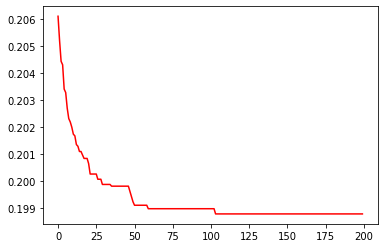

In [ ]:
import matplotlib.pyplot as plt

fig=plt.figure()
ax=fig.add_subplot()
fig.show()

ax.plot(mm, color='r')
fig.canvas.draw()

In [ ]:
Average_accuracy_with_FS=sum(average_accuracy)/len(average_accuracy)
Average_accuracy_with_FS

80.12202954399484

In [ ]:
Average_accuracy_without_FS=Fnew1
Average_accuracy_without_FS

78.9980732177264

In [ ]:
Average_no_of_features_selected=sum(average_feature)/len(average_feature)
Average_no_of_features_selected

4.5

In [ ]:
Average_fitness=mm
Average_fitness

array([0.20610148, 0.20520231, 0.2044316 , 0.20430315, 0.20340398,
       0.20327553, 0.2026975 , 0.20231214, 0.20218369, 0.20199101,
       0.2017341 , 0.20166988, 0.20134875, 0.20128452, 0.20109184,
       0.20109184, 0.20096339, 0.20083494, 0.20083494, 0.20083494,
       0.20064226, 0.2002569 , 0.2002569 , 0.2002569 , 0.2002569 ,
       0.2002569 , 0.20006423, 0.20006423, 0.20006423, 0.19987155,
       0.19987155, 0.19987155, 0.19987155, 0.19987155, 0.19987155,
       0.19980732, 0.19980732, 0.19980732, 0.19980732, 0.19980732,
       0.19980732, 0.19980732, 0.19980732, 0.19980732, 0.19980732,
       0.19980732, 0.19980732, 0.19961464, 0.19942197, 0.19922929,
       0.19910083, 0.19910083, 0.19910083, 0.19910083, 0.19910083,
       0.19910083, 0.19910083, 0.19910083, 0.19910083, 0.19897238,
       0.19897238, 0.19897238, 0.19897238, 0.19897238, 0.19897238,
       0.19897238, 0.19897238, 0.19897238, 0.19897238, 0.19897238,
       0.19897238, 0.19897238, 0.19897238, 0.19897238, 0.19897